In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [2]:
df = pd.read_csv("C:/projet/customer-segmentation/data/RFM.csv") 

In [3]:
df.head(10)

,Nom,Prenom,Date du dernier achat,date de fin,Distance date,R,Nombre d'achats (12 derniers mois),F,Montant total des achats (€),M,RFMscore\n
0,Vincent,Isaac,2/17/2025,6/16/2025,119,4.0,1.0,1.0,38.41,1.0,411.0
1,Caron,No?l,3/4/2025,6/16/2025,104,4.0,15.0,4.0,910.43,4.0,444.0
2,Grondin,Rémy,7/30/2024,6/16/2025,321,1.0,4.0,2.0,340.19,2.0,122.0
3,Vallet,Olivier,11/24/2024,6/16/2025,204,3.0,9.0,3.0,509.21,3.0,333.0
4,Louis,Josette,1/28/2025,6/16/2025,139,3.0,2.0,1.0,50.77,1.0,311.0
5,Boyer,Astrid,3/28/2025,6/16/2025,80,5.0,2.0,1.0,81.41,1.0,511.0
6,Alves,Jeannine,1/28/2025,6/16/2025,139,3.0,11.0,3.0,1088.59,3.0,333.0
7,Raymond,Luce,11/3/2024,6/16/2025,225,2.0,4.0,2.0,227.23,2.0,222.0
8,Le Roux,Sabine,9/18/2024,6/16/2025,271,2.0,13.0,4.0,825.33,4.0,244.0
9,Boulay,Marine,11/7/2024,6/16/2025,221,2.0,3.0,1.0,63.45,1.0,211.0


In [4]:
df.shape

(160, 11)

In [5]:
df.columns

Index(['Nom', 'Prenom', 'Date du dernier achat', 'date de fin',
       'Distance date', 'R', 'Nombre d'achats (12 derniers mois)', 'F',
       'Montant total des achats (€)', 'M', 'RFMscore\n'],
      dtype='object')

In [6]:
df.dtypes

Nom                                    object
Prenom                                 object
Date du dernier achat                  object
date de fin                            object
Distance date                          object
R                                     float64
Nombre d'achats (12 derniers mois)    float64
F                                     float64
Montant total des achats (€)          float64
M                                     float64
RFMscore\n                            float64
dtype: object

In [7]:
df.describe()

,R,Nombre d'achats (12 derniers mois),F,Montant total des achats (€),M,RFMscore\n
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,3.000000,10.466667,3.160000,606.041867,3.160000,334.760000
std,1.418951,5.838620,1.361405,460.389365,1.361405,142.993297
min,1.000000,1.000000,1.000000,38.410000,1.000000,111.000000
25%,2.000000,5.000000,2.000000,230.860000,2.000000,222.000000
50%,3.000000,10.000000,3.000000,504.825000,3.000000,333.000000
75%,4.000000,16.000000,4.000000,824.462500,4.000000,452.250000
max,5.000000,20.000000,5.000000,1719.820000,5.000000,555.000000


In [8]:
df.isnull().sum()

Nom                                   10
Prenom                                10
Date du dernier achat                 10
date de fin                           10
Distance date                          9
R                                     10
Nombre d'achats (12 derniers mois)    10
F                                     10
Montant total des achats (€)          10
M                                     10
RFMscore\n                            10
dtype: int64

In [9]:
df.duplicated().sum()

8

In [10]:
df.dropna(subset=['Nom'], inplace=True)

In [11]:
X = df[['R', 'F', 'M']]

In [12]:
#standarisation
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df[['R', 'F', 'M']])

c:\Users\QWER\anaconda3\envs\proba\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\QWER\anaconda3\envs\proba\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\QWER\anaconda3\envs\proba\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\QWER\anaconda3\envs\proba\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans 

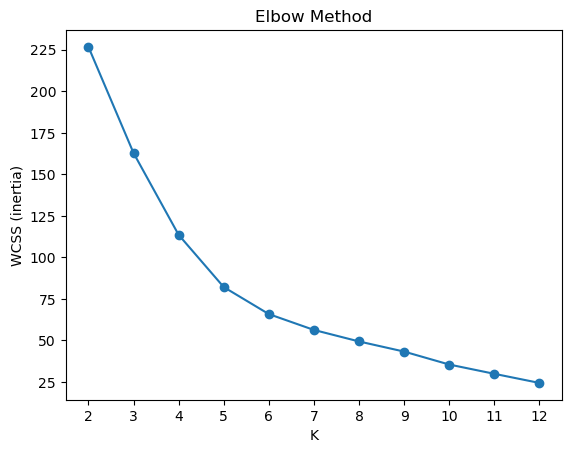

NameError: name 'out' is not defined

In [ ]:
##elbow find k
K_range = range(2, 13)
wcss = []   ##點到質心平方和
models = []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(rfm_scaled) ##訓練標準化之後的數據
    wcss.append(km.inertia_) ##存儲計算之後的質心
    models.append(km)##存儲每個k值下訓練好的模型

plt.figure()
plt.plot(list(K_range), wcss, marker='o')##x軸，y軸，點樣式
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS (inertia)")
plt.xticks(list(K_range))
plt.show()


In [14]:
best_k = 5
km = KMeans(n_clusters=best_k, n_init=50, random_state=42)
km.fit(rfm_scaled) ##訓練標準化之後的數據
labels = km.fit_predict(rfm_scaled)
df['cluster'] = labels

c:\Users\QWER\anaconda3\envs\proba\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\QWER\anaconda3\envs\proba\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [15]:
sil = silhouette_score(rfm_scaled, labels)
print(f"silhouette = {sil:.3f}  | sizes = {np.bincount(labels)}") ##輪廓係數評價

silhouette = 0.446  | sizes = [42 24 37 22 25]


In [16]:
##centers 給出中心
centers_scaled = km.cluster_centers_
centers = pd.DataFrame(
    scaler.inverse_transform(centers_scaled),  # 用你前面的 StandardScaler
    columns=['R','F','M']
).assign(cluster=range(best_k))
print(centers.sort_values('cluster'))

          R         F         M  cluster
0  1.738095  2.119048  2.119048        0
1  1.458333  4.500000  4.500000        1
2  4.054054  4.621622  4.621622        2
3  4.363636  1.409091  1.409091        3
4  3.840000  3.000000  3.000000        4


In [17]:
profile = df.groupby('cluster').agg(
    n=('cluster','size'),
    R_mean=('R','mean'), F_mean=('F','mean'), M_mean=('M','mean'),
    R_median=('R','median'), F_median=('F','median'), M_median=('M','median')
).sort_values('n', ascending=False)
print(profile)

          n    R_mean    F_mean    M_mean  R_median  F_median  M_median
cluster                                                                
0        42  1.738095  2.119048  2.119048       2.0       2.0       2.0
2        37  4.054054  4.621622  4.621622       4.0       5.0       5.0
4        25  3.840000  3.000000  3.000000       4.0       3.0       3.0
1        24  1.458333  4.500000  4.500000       1.0       4.5       4.5
3        22  4.363636  1.409091  1.409091       4.5       1.0       1.0


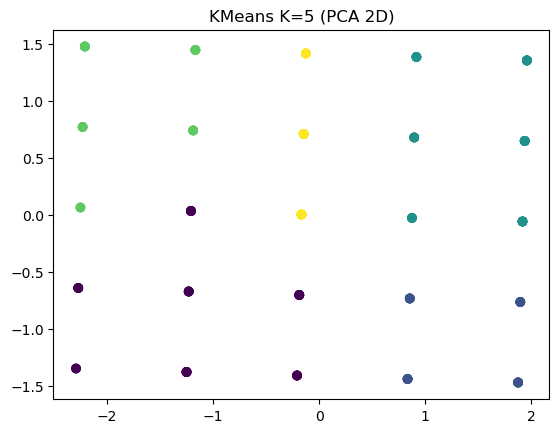

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Z = PCA(n_components=2, random_state=42).fit_transform(rfm_scaled)
plt.figure()
plt.scatter(Z[:,0], Z[:,1], c=labels)  # 简单看一下簇分布
plt.title(f"KMeans K={best_k} (PCA 2D)")
plt.show()


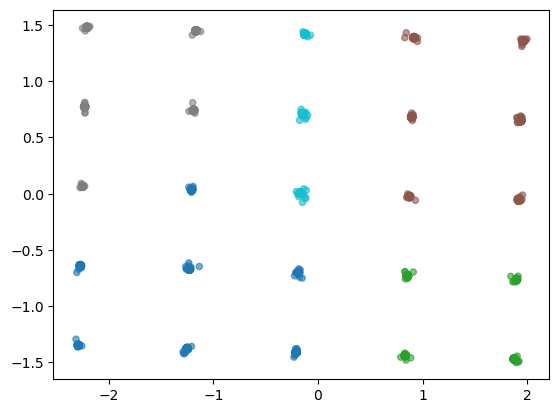

In [19]:
## Reduce standardized features (rfm_scaled) to 2 dimensions with PCA for visualization 用离散色盘，避免颜色渐变误导
plt.scatter(Z[:,0], Z[:,1], c=labels, cmap='tab10', s=35, alpha=0.9)

##  Plot each sample in the 2D PCA space; color by its KMeans-assigned cluster label轻微抖动，减少重叠（只为展示）
eps = 0.03
plt.scatter(Z[:,0]+np.random.randn(len(Z))*eps,
            Z[:,1]+np.random.randn(len(Z))*eps,
            c=labels, cmap='tab10', s=20, alpha=0.6)


In [ ]:
##Quick diagnostics (cluster sizes, silhouette, PCA variance)
import numpy as np
from sklearn.metrics import silhouette_score
print("sizes:", np.bincount(labels))                 # 每簇样本数
print("silhouette:", silhouette_score(rfm_scaled, labels))  # 分群质量（>0.25 基本可用）

from sklearn.decomposition import PCA
pca = PCA(n_components=3, random_state=42).fit(rfm_scaled)
print("PCA var (PC1,PC2,PC3):", pca.explained_variance_ratio_,
      "sum(PC1+PC2)=", pca.explained_variance_ratio_[:2].sum())
# 如果 PC1+PC2 < 0.6，2D 投影损失信息较多，本来就不容易“看出5簇”


sizes: [42 24 37 22 25]
silhouette: 0.44639551432035013
PCA var (PC1,PC2,PC3): [6.66956102e-01 3.33043898e-01 6.73242735e-17] sum(PC1+PC2)= 1.0


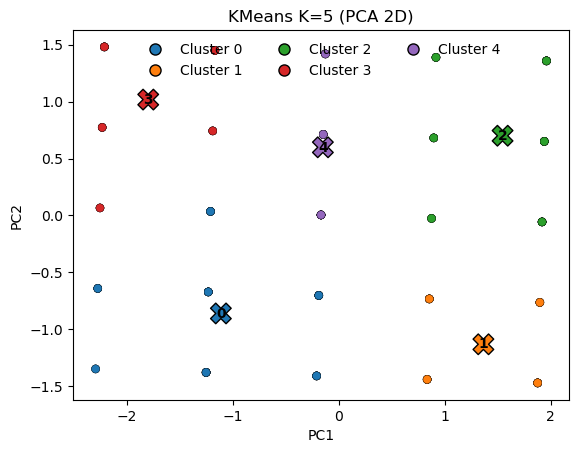

In [ ]:
##PCA 2D scatter with discrete colors + centroid markers + legend
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA

cmap = ListedColormap(['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd'])  # 5 个离散颜色

pca2 = PCA(n_components=2, random_state=42).fit(rfm_scaled)
Z = pca2.transform(rfm_scaled)

plt.figure()
plt.scatter(Z[:,0], Z[:,1], c=labels, cmap=cmap, s=35, alpha=0.9, edgecolors='k', linewidths=0.2)

# 画出簇中心（投影到同一 PCA 空间）
centers_2d = pca2.transform(km.cluster_centers_)
plt.scatter(centers_2d[:,0], centers_2d[:,1], c=range(km.n_clusters), cmap=cmap,
            marker='X', s=220, edgecolors='k', linewidths=1.0)
for i,(x,y) in enumerate(centers_2d):
    plt.text(x, y, str(i), ha='center', va='center', fontsize=10, weight='bold')

# 简单图例
handles = [plt.Line2D([0],[0], marker='o', color='w', label=f'Cluster {i}',
                      markerfacecolor=cmap(i), markeredgecolor='k', markersize=8)
           for i in range(km.n_clusters)]
plt.legend(handles=handles, frameon=False, ncol=3)

plt.title(f"KMeans K={km.n_clusters} (PCA 2D)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()


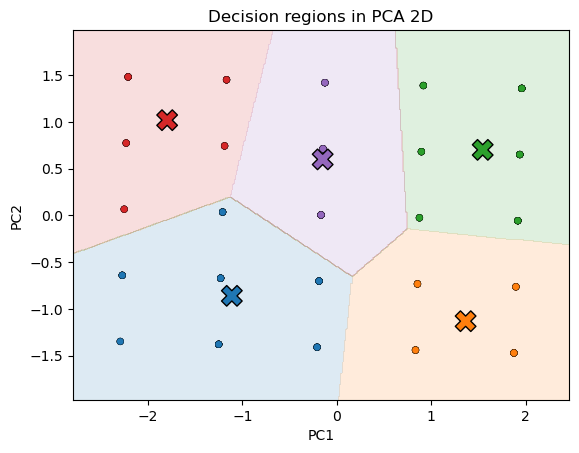

In [ ]:
##Decision regions (cluster boundaries) in the PCA 2D plane
import numpy as np
xx, yy = np.meshgrid(np.linspace(Z[:,0].min()-0.5, Z[:,0].max()+0.5, 400),
                     np.linspace(Z[:,1].min()-0.5, Z[:,1].max()+0.5, 400))
grid_pca = np.c_[xx.ravel(), yy.ravel()]
# 把 PCA 平面上的网格点“反投影”回标准化特征空间，再用 kmeans 预测簇
grid_scaled = pca2.inverse_transform(grid_pca)
pred = km.predict(grid_scaled).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, pred, levels=np.arange(km.n_clusters+1)-0.5, alpha=0.15, cmap=cmap)
plt.scatter(Z[:,0], Z[:,1], c=labels, cmap=cmap, s=25, edgecolors='k', linewidths=0.2)
plt.scatter(centers_2d[:,0], centers_2d[:,1], c=range(km.n_clusters), cmap=cmap,
            marker='X', s=220, edgecolors='k')
plt.title("Decision regions in PCA 2D"); plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()


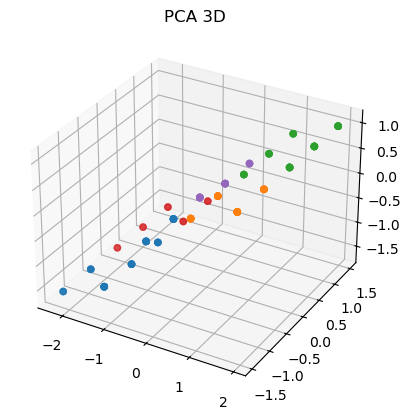

In [ ]:
##3D PCA scatter (keeps more structure than 2D)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
Z3 = PCA(n_components=3, random_state=42).fit_transform(rfm_scaled)
ax = plt.figure().add_subplot(111, projection='3d')
ax.scatter(Z3[:,0], Z3[:,1], Z3[:,2], c=labels, cmap=cmap, s=20)
ax.set_title("PCA 3D"); plt.show()


In [21]:
df.to_csv("clustered_output.csv", index=False)
centers.to_csv("cluster_centers.csv", index=False)
profile.to_csv("cluster_profile.csv", index=False)
